# **IMPORTING LIABRARIES **

In [ ]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Models
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# Metrics
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

# **IMPORTING DATASET**

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving part_5_customer_ltv_prediction.xlsx to part_5_customer_ltv_prediction (1).xlsx


In [ ]:
df = pd.read_excel('part_5_customer_ltv_prediction.xlsx')

# **UNDERSTANDING DATASET**

In [ ]:
# displaying first five rows of dataset
df.head()

,CustomerID,Age,AnnualIncome,WebsiteVisits,AppSessions,PreviousOrders,AverageOrderValue,DaysSinceLastPurchase,ReturnRate,CancellationRate,LoyaltyTier,DiscountUsedLastCampaign,Year1Spending,FutureSpending
0,LTV00001,33,64196.02,145,61,19,1403.79,242,0.136,0.028,Gold,No,25356.80,12438.46
1,LTV00002,46,69889.53,153,111,2,988.47,223,0.126,0.067,Silver,Yes,2768.68,5860.22
2,LTV00003,20,83269.51,175,112,34,2386.24,101,0.026,0.087,Silver,No,80895.63,39203.34
3,LTV00004,44,79914.63,22,80,0,1121.87,98,0.037,0.004,Gold,Yes,874.95,3157.73
4,LTV00005,26,84091.39,24,166,12,1942.48,256,0.052,0.004,Gold,No,22962.40,11423.53


In [ ]:
# diplaying count of rows and columns
df.shape

(1400, 14)

In [ ]:
# displaying column names
df.columns

Index(['CustomerID', 'Age', 'AnnualIncome', 'WebsiteVisits', 'AppSessions',
       'PreviousOrders', 'AverageOrderValue', 'DaysSinceLastPurchase',
       'ReturnRate', 'CancellationRate', 'LoyaltyTier',
       'DiscountUsedLastCampaign', 'Year1Spending', 'FutureSpending'],
      dtype='object')

In [ ]:
# displaying information of dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1400 entries, 0 to 1399
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CustomerID                1400 non-null   object 
 1   Age                       1400 non-null   int64  
 2   AnnualIncome              1391 non-null   float64
 3   WebsiteVisits             1400 non-null   int64  
 4   AppSessions               1400 non-null   int64  
 5   PreviousOrders            1400 non-null   int64  
 6   AverageOrderValue         1390 non-null   float64
 7   DaysSinceLastPurchase     1400 non-null   int64  
 8   ReturnRate                1400 non-null   float64
 9   CancellationRate          1400 non-null   float64
 10  LoyaltyTier               1400 non-null   object 
 11  DiscountUsedLastCampaign  1400 non-null   object 
 12  Year1Spending             1400 non-null   float64
 13  FutureSpending            1400 non-null   float64
dtypes: float

In [ ]:
# displayinf statistical summary of dataset
df.describe()

,Age,AnnualIncome,WebsiteVisits,AppSessions,PreviousOrders,AverageOrderValue,DaysSinceLastPurchase,ReturnRate,CancellationRate,Year1Spending,FutureSpending
count,1400.000000,1391.000000,1400.000000,1400.000000,1400.000000,1390.000000,1400.000000,1400.00000,1400.000000,1400.000000,1400.00000
mean,41.605714,71444.250453,90.737143,132.418571,6.565714,1415.577691,183.185000,0.15199,0.108642,9134.559429,6313.12205
std,13.805044,24377.868323,52.795743,74.377160,7.040268,560.500299,104.939899,0.11240,0.090918,10302.771512,4753.00922
min,18.000000,18000.000000,0.000000,0.000000,0.000000,120.000000,0.000000,0.00000,0.000000,2.720000,0.00000
25%,30.000000,53835.975000,44.000000,69.000000,2.000000,1047.412500,90.000000,0.06800,0.041000,2141.730000,3268.38000
50%,41.000000,71166.060000,91.000000,135.000000,4.000000,1405.770000,182.000000,0.12600,0.085000,5961.810000,5169.58500
75%,54.000000,87956.155000,138.000000,195.000000,9.000000,1787.925000,272.000000,0.21400,0.150250,12564.177500,8096.47750
max,65.000000,151693.240000,180.000000,260.000000,65.000000,3206.800000,365.000000,0.73500,0.605000,118597.670000,54797.19000


# **DATA CLEANING **

In [ ]:
# MISING VALUE CHECK
print(df.isnull().sum())

CustomerID                   0
Age                          0
AnnualIncome                 9
WebsiteVisits                0
AppSessions                  0
PreviousOrders               0
AverageOrderValue           10
DaysSinceLastPurchase        0
ReturnRate                   0
CancellationRate             0
LoyaltyTier                  0
DiscountUsedLastCampaign     0
Year1Spending                0
FutureSpending               0
dtype: int64


In [ ]:
# HANDLING MISSING VALUES of average order value
median_AverageOrderValue = df['AverageOrderValue'].median()
df['AverageOrderValue'].fillna(median_AverageOrderValue, inplace=True)

print("Missing values after imputation:")
print(df.isnull().sum())

Missing values after imputation:
CustomerID                  0
Age                         0
AnnualIncome                9
WebsiteVisits               0
AppSessions                 0
PreviousOrders              0
AverageOrderValue           0
DaysSinceLastPurchase       0
ReturnRate                  0
CancellationRate            0
LoyaltyTier                 0
DiscountUsedLastCampaign    0
Year1Spending               0
FutureSpending              0
dtype: int64


/tmp/ipykernel_16955/3870049399.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['AverageOrderValue'].fillna(median_AverageOrderValue, inplace=True)


In [ ]:
# HANDLING MISSING VALUES of Annual income
median_AnnualIncome  = df['AnnualIncome'].median()
df['AnnualIncome'].fillna(median_AnnualIncome , inplace=True)

print("Missing values after imputation:")
print(df.isnull().sum())

Missing values after imputation:
CustomerID                  0
Age                         0
AnnualIncome                0
WebsiteVisits               0
AppSessions                 0
PreviousOrders              0
AverageOrderValue           0
DaysSinceLastPurchase       0
ReturnRate                  0
CancellationRate            0
LoyaltyTier                 0
DiscountUsedLastCampaign    0
Year1Spending               0
FutureSpending              0
dtype: int64


/tmp/ipykernel_16955/1008380638.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['AnnualIncome'].fillna(median_AnnualIncome , inplace=True)


In [ ]:
# CHECKING FOR DUPLICATES
print(f"Number of duplicate rows: {df.duplicated().sum()}")

Number of duplicate rows: 0


In [ ]:
#CHECKING DATATYPES
df.dtypes

,0
CustomerID,object
Age,int64
AnnualIncome,float64
WebsiteVisits,int64
AppSessions,int64
PreviousOrders,int64
AverageOrderValue,float64
DaysSinceLastPurchase,int64
ReturnRate,float64
CancellationRate,float64


In [ ]:
# Changing datatype
df['DiscountUsedLastCampaign'] = df['DiscountUsedLastCampaign'].astype('category')

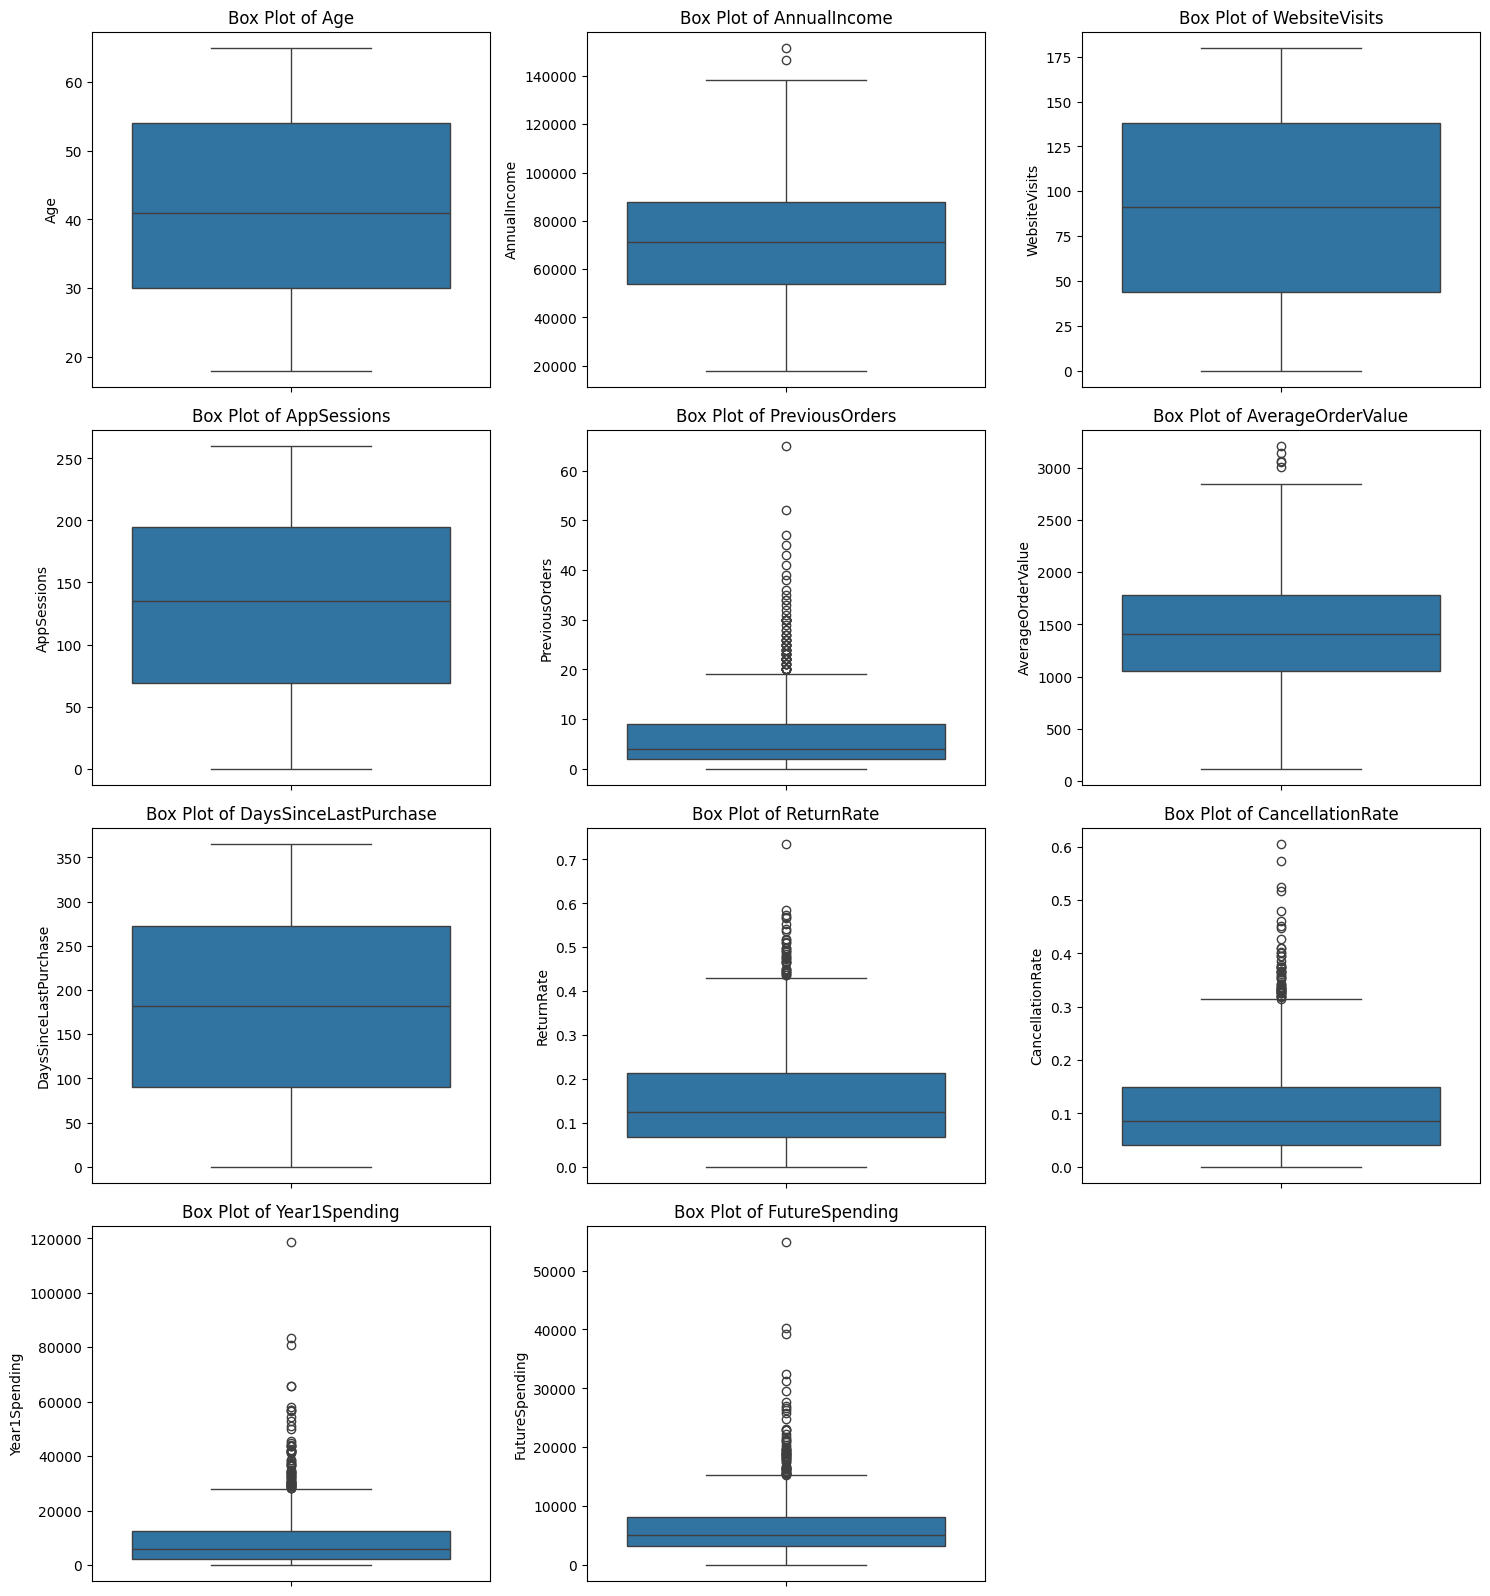

In [ ]:
# IDENTIFYING OUTLIERS
# Exclude non-numerical columns from this list for box plots
numerical_cols = [ 'Age', 'AnnualIncome', 'WebsiteVisits', 'AppSessions',
       'PreviousOrders', 'AverageOrderValue', 'DaysSinceLastPurchase',
       'ReturnRate', 'CancellationRate', 'Year1Spending', 'FutureSpending']

# Adjust subplot grid to accommodate all numerical columns
# 5 rows x 3 columns = 15 plots, sufficient for 11 numerical columns
plt.figure(figsize=(15, 20)) # Increased figure size to accommodate more rows
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(5, 3, i) # Changed grid from (2, 3) to (5, 3)
    sns.boxplot(y=df[col])
    plt.title(f'Box Plot of {col}')
plt.tight_layout()
plt.show()

# **FEATURE ENGINEERING**

### Feature 1: Total Visits
Combining `WebsiteVisits` and `AppSessions` to get an overall measure of customer interaction with the platforms.

In [ ]:
df['TotalVisits'] = df['WebsiteVisits'] + df['AppSessions']
print(df[['WebsiteVisits', 'AppSessions', 'TotalVisits']].head())

   WebsiteVisits  AppSessions  TotalVisits
0            145           61          206
1            153          111          264
2            175          112          287
3             22           80          102
4             24          166          190


### Feature 2: Engagement Score
A composite score reflecting overall customer engagement, considering visits and previous orders.

In [ ]:
df['EngagementScore'] = df['TotalVisits'] + df['PreviousOrders']
print(df[['TotalVisits', 'PreviousOrders', 'EngagementScore']].head())

   TotalVisits  PreviousOrders  EngagementScore
0          206              19              225
1          264               2              266
2          287              34              321
3          102               0              102
4          190              12              202


### Feature 3: Spending Growth
Calculating the absolute difference between `FutureSpending` and `Year1Spending` to see the growth in spending, and a spending growth rate.

In [ ]:
df['SpendingGrowth'] = df['FutureSpending'] - df['Year1Spending']

# Calculate SpendingGrowthRate, handling division by zero
df['SpendingGrowthRate'] = df.apply(lambda row: (row['FutureSpending'] - row['Year1Spending']) / row['Year1Spending'] if row['Year1Spending'] != 0 else 0, axis=1)

print(df[['Year1Spending', 'FutureSpending', 'SpendingGrowth', 'SpendingGrowthRate']].head())

   Year1Spending  FutureSpending  SpendingGrowth  SpendingGrowthRate
0       25356.80        12438.46       -12918.34           -0.509463
1        2768.68         5860.22         3091.54            1.116612
2       80895.63        39203.34       -41692.29           -0.515384
3         874.95         3157.73         2282.78            2.609041
4       22962.40        11423.53       -11538.87           -0.502511


### Other Features

*   **Total orders**: The `PreviousOrders` column already represents the total number of past orders.
*   **Average order value**: The `AverageOrderValue` column is already available.
*   **Total previous spending**: The `Year1Spending` column represents the total spending in the first year.
*   **Recency**: The `DaysSinceLastPurchase` column can be used directly as a measure of recency; lower values indicate higher recency.
*   **Return rate**: The `ReturnRate` column is already present.
*   **Cancellation rate**: The `CancellationRate` column is already present.

In [ ]:
# Display the updated DataFrame with new features
display(df.head())

,CustomerID,Age,AnnualIncome,WebsiteVisits,AppSessions,PreviousOrders,AverageOrderValue,DaysSinceLastPurchase,ReturnRate,CancellationRate,LoyaltyTier,DiscountUsedLastCampaign,Year1Spending,FutureSpending,TotalVisits,SpendingGrowth,SpendingGrowthRate
0,LTV00001,33,64196.02,145,61,19,1403.79,242,0.136,0.028,Gold,No,25356.80,12438.46,206,-12918.34,-0.509463
1,LTV00002,46,69889.53,153,111,2,988.47,223,0.126,0.067,Silver,Yes,2768.68,5860.22,264,3091.54,1.116612
2,LTV00003,20,83269.51,175,112,34,2386.24,101,0.026,0.087,Silver,No,80895.63,39203.34,287,-41692.29,-0.515384
3,LTV00004,44,79914.63,22,80,0,1121.87,98,0.037,0.004,Gold,Yes,874.95,3157.73,102,2282.78,2.609041
4,LTV00005,26,84091.39,24,166,12,1942.48,256,0.052,0.004,Gold,No,22962.40,11423.53,190,-11538.87,-0.502511


# **EXPLORATORY DATA ANALYSIS**

### 1 Distribution of Customer Spending

Let's visualize the distribution of `Year1Spending` and `FutureSpending` to understand the overall spending patterns of customers.

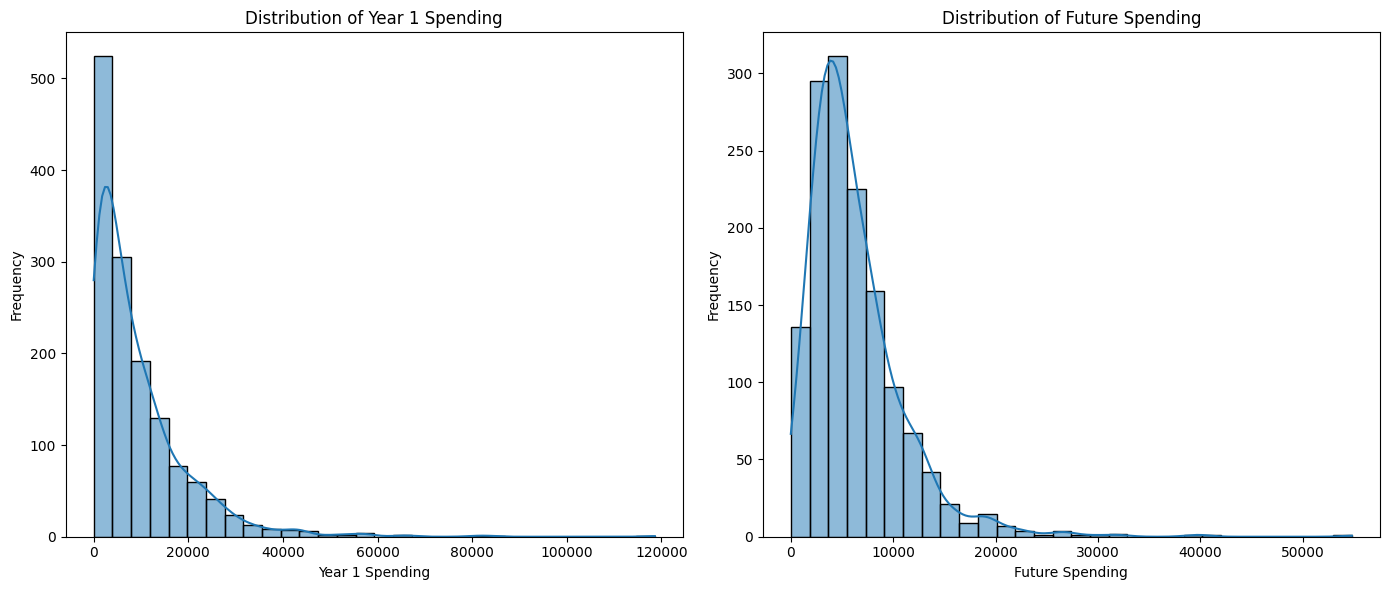

In [ ]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.histplot(df['Year1Spending'], kde=True, bins=30)
plt.title('Distribution of Year 1 Spending')
plt.xlabel('Year 1 Spending')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.histplot(df['FutureSpending'], kde=True, bins=30)
plt.title('Distribution of Future Spending')
plt.xlabel('Future Spending')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()


# Interpretation
Interpretation: Both Year 1 and Future Spending distributions appear to be right-skewed, with a large number of customers having lower spending and a long tail indicating some high-spending customers. Future Spending seems to have a lower average than Year 1 Spending for many customers.

### 2 Relationship Between Income and Spending

We will use scatter plots to observe how `AnnualIncome` relates to both `Year1Spending` and `FutureSpending`.

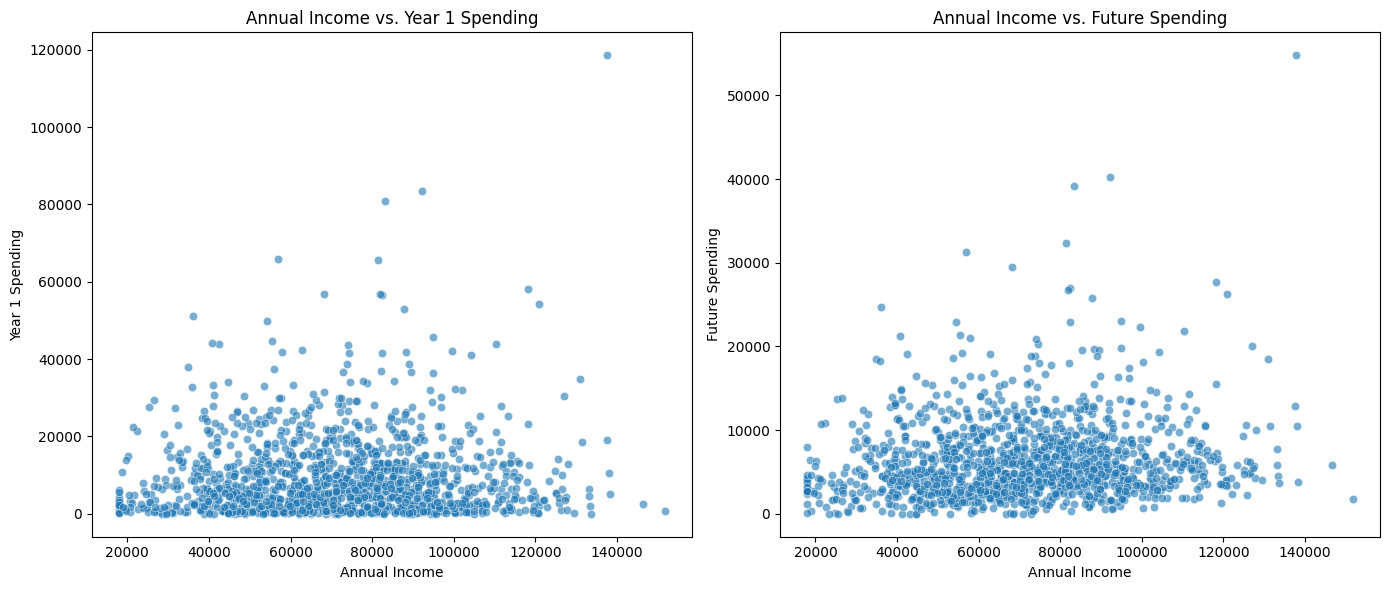

In [ ]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.scatterplot(x='AnnualIncome', y='Year1Spending', data=df, alpha=0.6)
plt.title('Annual Income vs. Year 1 Spending')
plt.xlabel('Annual Income')
plt.ylabel('Year 1 Spending')

plt.subplot(1, 2, 2)
sns.scatterplot(x='AnnualIncome', y='FutureSpending', data=df, alpha=0.6)
plt.title('Annual Income vs. Future Spending')
plt.xlabel('Annual Income')
plt.ylabel('Future Spending')

plt.tight_layout()
plt.show()

# Interpretation
Interpretation: There appears to be a positive correlation between Annual Income and both Year 1 Spending and Future Spending. Customers with higher annual incomes tend to have higher spending, though there's considerable spread.

### 3 Relationship Between Website Visits and Spending

Let's examine the relationship between `TotalVisits` (combining website and app sessions) and `FutureSpending` using a scatter plot.

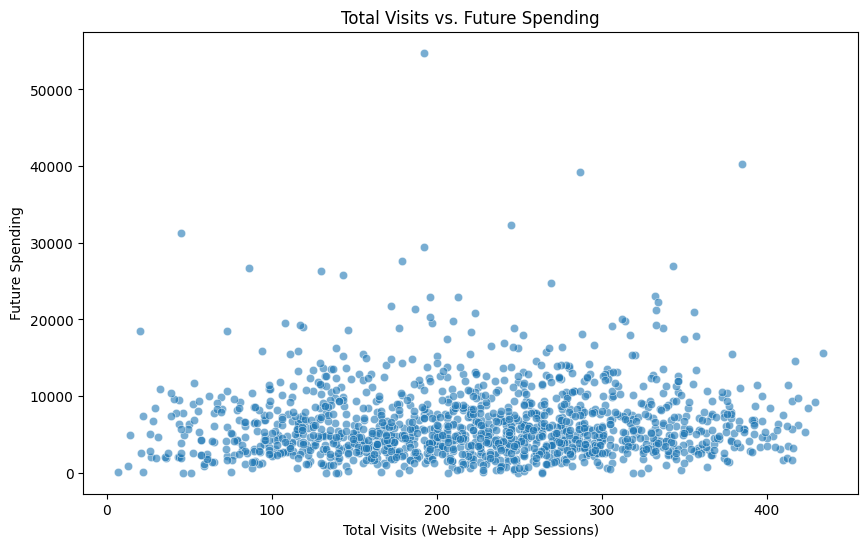

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='TotalVisits', y='FutureSpending', data=df, alpha=0.6)
plt.title('Total Visits vs. Future Spending')
plt.xlabel('Total Visits (Website + App Sessions)')
plt.ylabel('Future Spending')
plt.show()

# Interpretation
Interpretation: It appears that customers with more total visits tend to have higher future spending, suggesting that engagement with platforms influences purchasing behavior.

### 4 Relationship Between Previous Spending and Future Spending

This is a crucial relationship for LTV prediction. We'll visualize how `Year1Spending` correlates with `FutureSpending`.

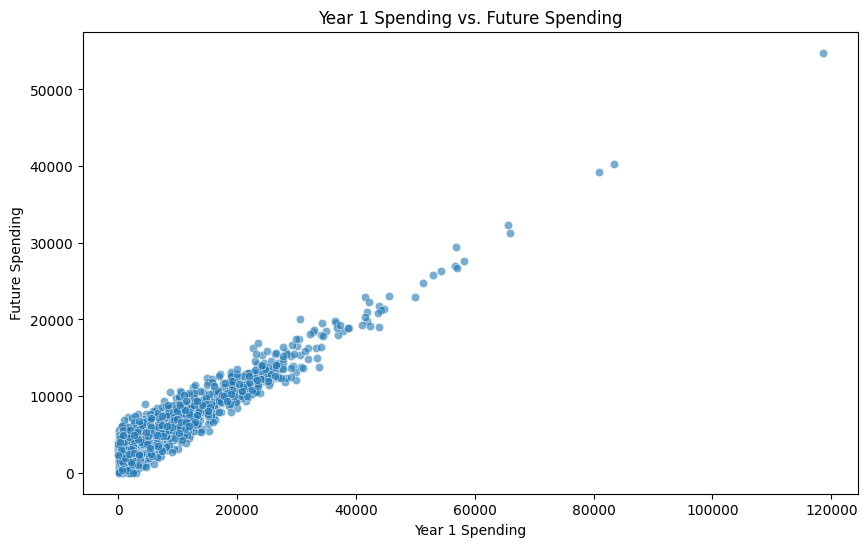

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Year1Spending', y='FutureSpending', data=df, alpha=0.6)
plt.title('Year 1 Spending vs. Future Spending')
plt.xlabel('Year 1 Spending')
plt.ylabel('Future Spending')
plt.show()

# Interpretation
Interpretation: There's a strong positive correlation between Year 1 Spending and Future Spending. Customers who spent more in their first year tend to spend more in the future, which is an expected and important indicator for LTV.

### 5 Relationship Between Order Count and Future Spending

Let's see if the number of `PreviousOrders` has an impact on `FutureSpending`.

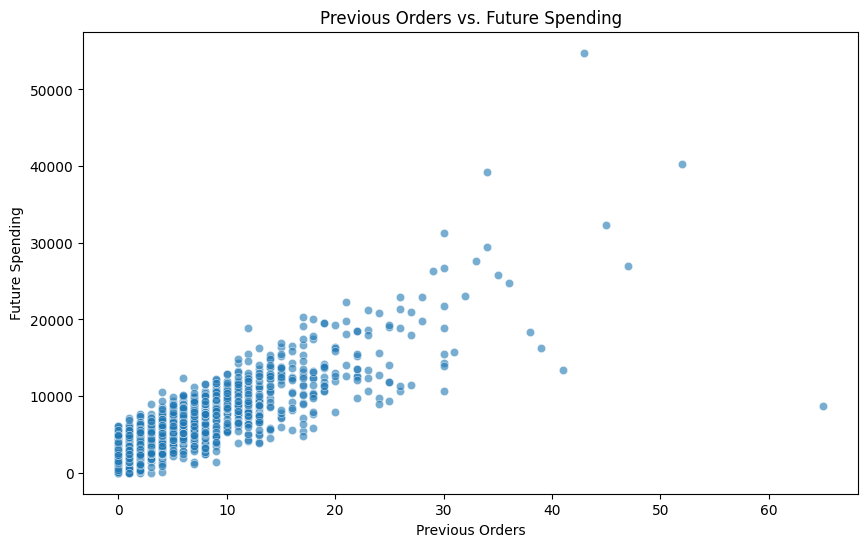

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='PreviousOrders', y='FutureSpending', data=df, alpha=0.6)
plt.title('Previous Orders vs. Future Spending')
plt.xlabel('Previous Orders')
plt.ylabel('Future Spending')
plt.show()

# Interpretation
Interpretation: A higher number of previous orders generally correlates with higher future spending, indicating that frequent buyers tend to remain high-value customers.

### 6 Correlation Between Numerical Features

To understand the linear relationships between all numerical features, we'll generate a correlation heatmap.

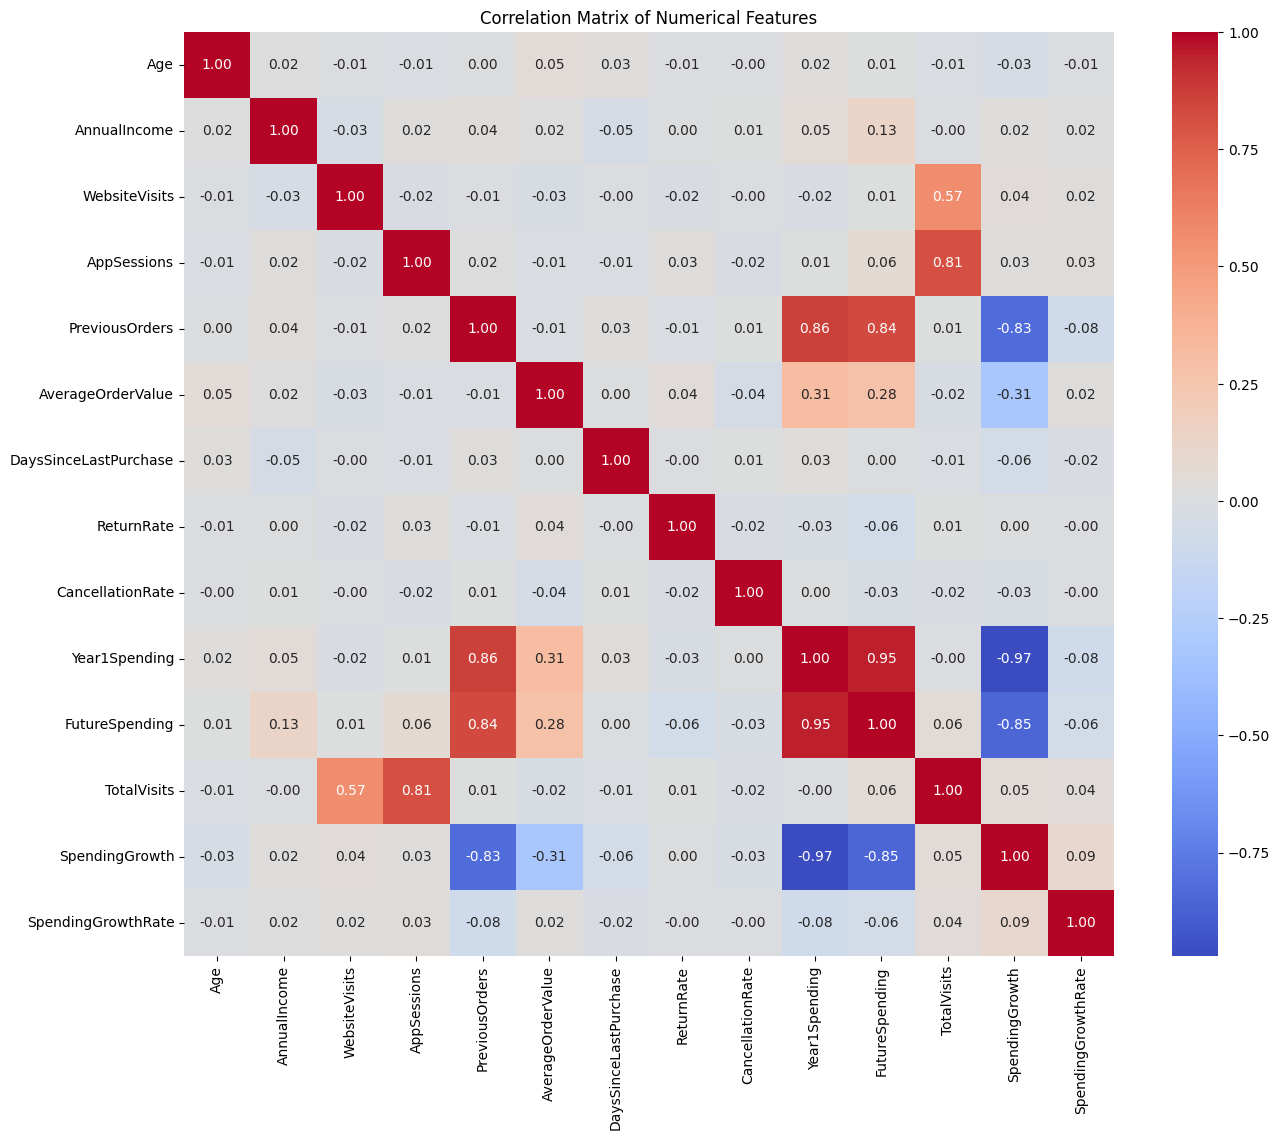

In [ ]:
plt.figure(figsize=(15, 12))

# Combine numerical_cols with the engineered features
all_cols_for_correlation = numerical_cols + ['TotalVisits', 'EngagementScore', 'SpendingGrowth', 'SpendingGrowthRate']

# Filter to include only columns that actually exist in df
existing_cols_for_correlation = [col for col in all_cols_for_correlation if col in df.columns]

sns.heatmap(df[existing_cols_for_correlation].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

# Interpretation
Interpretation: The heatmap provides a comprehensive view of inter-feature relationships. Key observations include strong positive correlations of Future Spending with Year 1 Spending, Annual Income, Previous Orders, and Average Order Value. Negative correlations might indicate inverse relationships, which could also be informative.

### 7 Outliers in Customer Value

We previously identified outliers using box plots for various numerical columns. For `FutureSpending`, which represents customer value, we can specifically look at its box plot again to identify extreme values.

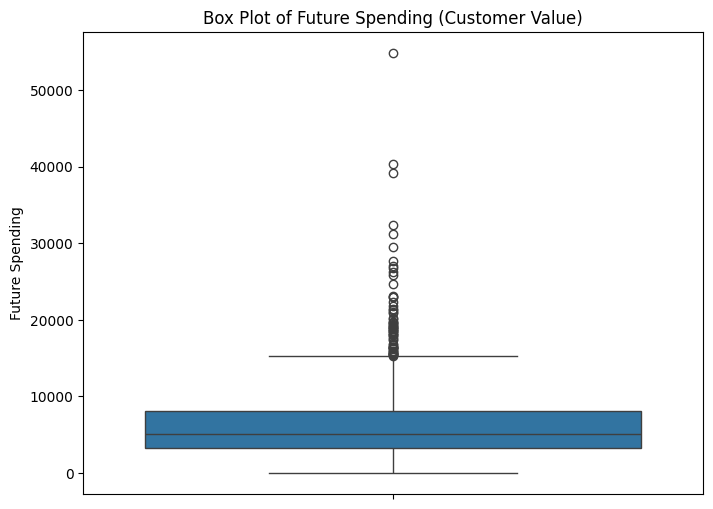

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(y=df['FutureSpending'])
plt.title('Box Plot of Future Spending (Customer Value)')
plt.ylabel('Future Spending')
plt.show()

# Interpretation
Interpretation: The box plot for Future Spending clearly shows several outliers, indicating customers with exceptionally high future spending compared to the majority. These high-value customers are important to identify and understand.

# **Customer Segmentation**


### Feature Preparation and Scaling for Clustering

In [ ]:
from sklearn.preprocessing import StandardScaler

# Assuming df_encoded is available from previous steps with one-hot encoded 'LoyaltyTier' and 'DiscountUsedLastCampaign'
# If not, you would need to run: df_encoded = pd.get_dummies(df, columns=['LoyaltyTier', 'DiscountUsedLastCampaign'], drop_first=False)

# Features selected for clustering
# Ensure these columns exist in df_encoded before proceeding
features_for_segmentation = [
    'Age', 'AnnualIncome', 'WebsiteVisits', 'AppSessions', 'PreviousOrders',
    'AverageOrderValue', 'DaysSinceLastPurchase', 'ReturnRate', 'CancellationRate',
    'Year1Spending', 'FutureSpending', 'TotalVisits', 'EngagementScore', 'SpendingGrowth',
    'LoyaltyTier_Gold', 'LoyaltyTier_Silver', 'LoyaltyTier_Bronze',
    'DiscountUsedLastCampaign_Yes', 'DiscountUsedLastCampaign_No'
]

# Create a segment-specific DataFrame using df_encoded
df_segment = df_encoded[features_for_segmentation].copy()

# Scale the features
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_segment)

df_scaled = pd.DataFrame(df_scaled, columns=df_segment.columns)

print("Data prepared and scaled for segmentation:")
display(df_scaled.head())

Data prepared and scaled for segmentation:


,Age,AnnualIncome,WebsiteVisits,AppSessions,PreviousOrders,AverageOrderValue,DaysSinceLastPurchase,ReturnRate,CancellationRate,Year1Spending,FutureSpending,TotalVisits,EngagementScore,SpendingGrowth,LoyaltyTier_Gold,LoyaltyTier_Silver,LoyaltyTier_Bronze,DiscountUsedLastCampaign_Yes,DiscountUsedLastCampaign_No
0,-0.623597,-0.298322,1.028156,-0.960565,1.766798,-0.020988,0.560664,-0.142311,-0.887293,1.575114,1.289189,-0.190024,-0.052090,-1.698484,1.973602,-0.637993,-0.885121,-0.845982,0.845982
1,0.318424,-0.063931,1.179737,-0.288075,-0.648746,-0.764897,0.379543,-0.231311,-0.458182,-0.618101,-0.095321,0.452410,0.400247,0.994671,-0.506688,1.567415,-0.885121,1.182058,-1.182058
2,-1.565619,0.486897,1.596586,-0.274626,3.898160,1.738746,-0.783442,-1.121310,-0.238125,6.967709,6.922345,0.707168,1.007041,-6.538791,-0.506688,1.567415,-0.885121,-0.845982,0.845982
3,0.173498,0.348783,-1.302410,-0.705019,-0.932928,-0.525955,-0.812040,-1.023410,-1.151361,-0.801975,-0.664110,-1.341975,-1.409101,0.858623,1.973602,-0.637993,-0.885121,1.182058,-1.182058
4,-1.130840,0.520732,-1.264515,0.451663,0.772162,0.943897,0.694121,-0.889910,-1.151361,1.342627,1.075578,-0.367247,-0.305840,-1.466432,1.973602,-0.637993,-0.885121,-0.845982,0.845982


###  Determining Optimal Number of Clusters (Elbow Method)

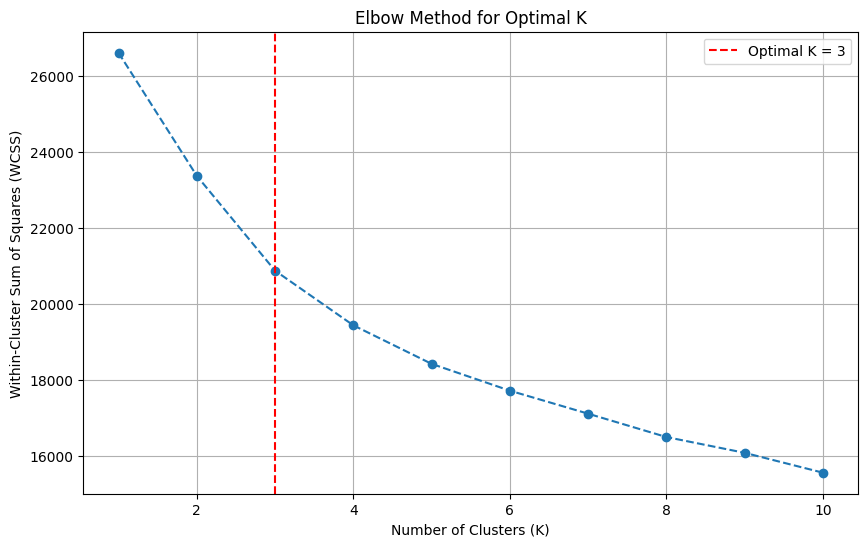

Visually inspect the plot above to find the 'elbow' point, which suggests the optimal number of clusters (k).


In [ ]:
from sklearn.cluster import KMeans

wcss = []
# Test a range of cluster numbers (e.g., from 1 to 10)
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    wcss.append(kmeans.inertia_)

# Plotting the Elbow Method graph
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.grid(True)

# Add a vertical line to highlight k=3
plt.axvline(x=3, color='red', linestyle='--', label='Optimal K = 3')
plt.legend()

plt.show()

print("Visually inspect the plot above to find the 'elbow' point, which suggests the optimal number of clusters (k).")

### Applying K-Means Clustering

In [ ]:
# Based on the Elbow Method plot, let's select the optimal number of clusters.
# For this example, we'll assume 5 clusters, but you can adjust this based on your visual inspection.
optimal_clusters = 3

kmeans = KMeans(n_clusters=optimal_clusters, init='k-means++', random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(df_scaled)

# Assign cluster labels back to the original DataFrame
df['Cluster'] = cluster_labels
df_encoded['Cluster'] = cluster_labels # Also add to df_encoded for consistency if used later

print(f"Customers segmented into {optimal_clusters} clusters:")
display(df[['CustomerID', 'Cluster']].head())

Customers segmented into 3 clusters:


,CustomerID,Cluster
0,LTV00001,2
1,LTV00002,1
2,LTV00003,2
3,LTV00004,0
4,LTV00005,2


### Analyzing Cluster Characteristics

In [ ]:
# Add cluster labels to the segmented DataFrame for analysis
df_segment['Cluster'] = cluster_labels

# Calculate the mean of each feature for each cluster to understand their characteristics
cluster_analysis = df_segment.groupby('Cluster')[features_for_segmentation].mean()

print("Cluster Analysis (Mean Feature Values per Cluster):")
display(cluster_analysis)

print("\nThis table helps to interpret what each cluster represents by comparing their average feature values.")

Cluster Analysis (Mean Feature Values per Cluster):


,Age,AnnualIncome,WebsiteVisits,AppSessions,PreviousOrders,AverageOrderValue,DaysSinceLastPurchase,ReturnRate,CancellationRate,Year1Spending,FutureSpending,TotalVisits,EngagementScore,SpendingGrowth,LoyaltyTier_Gold,LoyaltyTier_Silver,LoyaltyTier_Bronze,DiscountUsedLastCampaign_Yes,DiscountUsedLastCampaign_No
Cluster,,,,,,,,,,,,,,,,,,,
0,42.217926,70768.081845,69.397188,71.702988,4.748682,1410.482847,184.437610,0.148067,0.109728,6478.160633,4888.913023,141.100176,145.848858,-1589.247610,0.244288,0.288225,0.414763,0.442882,0.557118
1,41.027419,71412.291339,109.754839,184.235484,4.117742,1333.476355,180.287097,0.154150,0.106061,5231.626774,4823.433613,293.990323,298.108065,-408.193161,0.180645,0.280645,0.458065,0.391935,0.608065
2,41.654028,73349.704834,92.402844,143.890995,18.658768,1670.097678,188.322275,0.156223,0.113299,27766.356398,14531.045118,236.293839,254.952607,-13235.311280,0.165877,0.317536,0.450237,0.421801,0.578199



This table helps to interpret what each cluster represents by comparing their average feature values.


### Visualizing Clusters with PCA

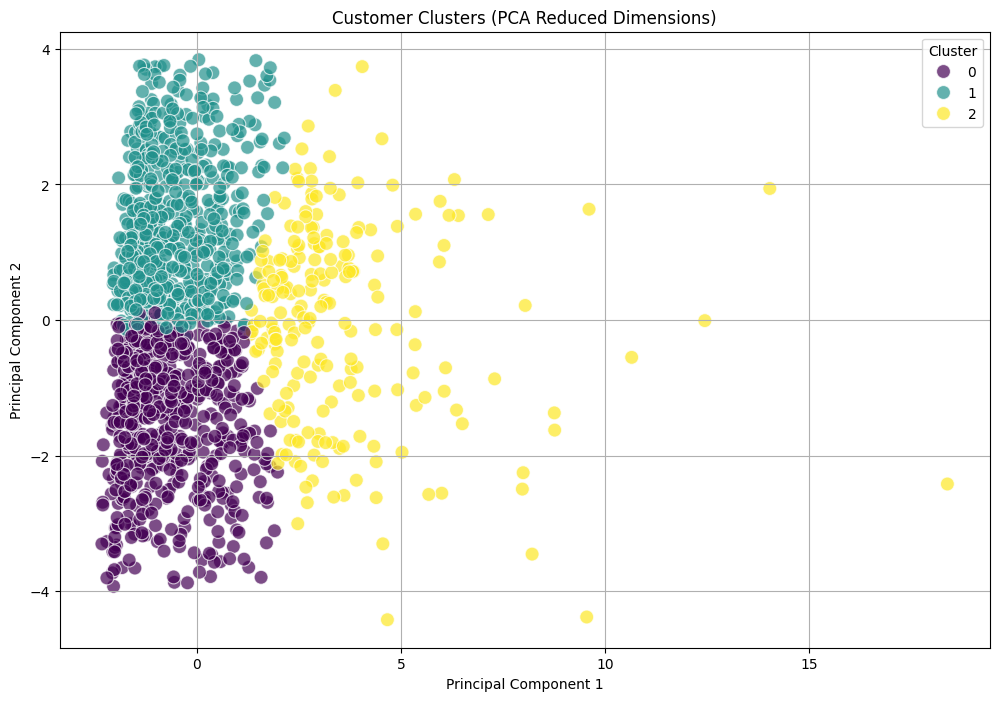

The PCA plot helps visualize the separation and distribution of the clusters in a 2D space.


In [ ]:
from sklearn.decomposition import PCA

# Apply PCA to reduce to 2 dimensions for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(df_scaled)

# Create a DataFrame for the PCA results
pca_df = pd.DataFrame(data=X_pca, columns=['Principal Component 1', 'Principal Component 2'])
pca_df['Cluster'] = df['Cluster'] # Add the cluster labels

# Visualize the clusters
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='Principal Component 1',
    y='Principal Component 2',
    hue='Cluster',
    data=pca_df,
    palette='viridis',
    s=100, # size of points
    alpha=0.7 # transparency
)
plt.title('Customer Clusters (PCA Reduced Dimensions)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

print("The PCA plot helps visualize the separation and distribution of the clusters in a 2D space.")

In [ ]:
# Define segment names based on the interpretation of your `cluster_analysis` for 3 clusters
segment_names = {
    0: 'Low Engagement, Low Spending Customers (Stable)',
    1: 'High Engagement, Medium Spending Customers (Potential Growth)',
    2: 'High Value, At-Risk Customers'
}

df['Segment'] = df['Cluster'].map(segment_names)

print("Customer counts per segment:")
display(df['Segment'].value_counts())

print("\nSegments defined and assigned to customers:")
display(df[['CustomerID', 'Cluster', 'Segment']].head())

Customer counts per segment:


,count
Segment,
"High Engagement, Medium Spending Customers (Potential Growth)",620
"Low Engagement, Low Spending Customers (Stable)",569
"High Value, At-Risk Customers",211



Segments defined and assigned to customers:


,CustomerID,Cluster,Segment
0,LTV00001,2,"High Value, At-Risk Customers"
1,LTV00002,1,"High Engagement, Medium Spending Customers (Po..."
2,LTV00003,2,"High Value, At-Risk Customers"
3,LTV00004,0,"Low Engagement, Low Spending Customers (Stable)"
4,LTV00005,2,"High Value, At-Risk Customers"


### Interpreting and Naming Customer Segments

By examining the mean values of the features within each cluster (from the `cluster_analysis` table), we can derive meaningful names for our customer segments. Here's an interpretation for 3 clusters, based on the current `cluster_analysis` output:

*   **Cluster 0: Low Engagement, Low Spending Customers (Stable)**
    *   **Engagement:** Lowest `WebsiteVisits`, `AppSessions`, `TotalVisits`, and `EngagementScore`.
    *   **Spending:** Lowest `Year1Spending` and `FutureSpending`.
    *   **Spending Growth:** Least negative `SpendingGrowth`, indicating stability at a lower spending level.
    *   **Loyalty:** Slightly higher proportion of `LoyaltyTier_Bronze`.
    *   **Conclusion:** These customers exhibit the lowest engagement and spending. They are stable but represent the lowest value segment.

*   **Cluster 1: High Engagement, Medium Spending Customers (Potential Growth)**
    *   **Engagement:** Highest `AppSessions`, very high `TotalVisits` and `EngagementScore`.
    *   **Spending:** Moderate `Year1Spending` and `FutureSpending`.
    *   **Previous Orders:** Lowest `PreviousOrders`.
    *   **Spending Growth:** Medium negative `SpendingGrowth`.
    *   **Conclusion:** These customers are highly engaged, especially via app, but their spending is moderate. This segment represents a strong potential for growth through targeted campaigns.

*   **Cluster 2: High Value, At-Risk Customers**
    *   **Spending:** Highest `Year1Spending` and `FutureSpending`.
    *   **Previous Orders:** Highest `PreviousOrders`.
    *   **Spending Growth:** Most negative `SpendingGrowth` (largest decrease in spending from Year 1 to Future Spending).
    *   **Engagement:** Medium-high `TotalVisits` and `EngagementScore`.
    *   **Conclusion:** Historically, these are the highest-value customers. However, the significant drop in `SpendingGrowth` suggests they are at risk of churning or decreasing their spending further, requiring retention strategies.

# **FUTURE SPENDING PREDICTIONS**

To predict `FutureSpending`, we'll first define our features (X) and target variable (y). We'll then split the data into training and testing sets. It's crucial to avoid using features that directly 'leak' future information or are direct transformations of the target variable for prediction. `SpendingGrowth` and `SpendingGrowthRate` are direct transformations that include `FutureSpending`, so these will be excluded from the feature set to prevent data leakage.

In [ ]:
# Define features (X) and target (y)
X = df.drop(['CustomerID', 'LoyaltyTier', 'DiscountUsedLastCampaign', 'FutureSpending', 'SpendingGrowth', 'SpendingGrowthRate', 'Cluster', 'Segment'], axis=1)
y = df['FutureSpending']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")

Training set size: 1120 samples
Test set size: 280 samples


### Linear Regression Model

In [ ]:
# Initialize and train the Linear Regression model
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_lr = linear_model.predict(X_test)

# Evaluate the model
mae_lr = mean_absolute_error(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Model Performance:")
print(f"Mean Absolute Error (MAE): {mae_lr:.2f}")
print(f"Mean Squared Error (MSE): {mse_lr:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_lr:.2f}")
print(f"R2 Score: {r2_lr:.2f}")

Linear Regression Model Performance:
Mean Absolute Error (MAE): 1058.77
Mean Squared Error (MSE): 1815990.06
Root Mean Squared Error (RMSE): 1347.59
R2 Score: 0.91


### Decision Tree Regressor Model

In [ ]:
# Initialize and train the Decision Tree Regressor model
dtree_model = DecisionTreeRegressor(random_state=42)
dtree_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_dt = dtree_model.predict(X_test)

# Evaluate the model
mae_dt = mean_absolute_error(y_test, y_pred_dt)
mse_dt = mean_squared_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mse_dt)
r2_dt = r2_score(y_test, y_pred_dt)

print("Decision Tree Regressor Model Performance:")
print(f"Mean Absolute Error (MAE): {mae_dt:.2f}")
print(f"Mean Squared Error (MSE): {mse_dt:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_dt:.2f}")
print(f"R2 Score: {r2_dt:.2f}")

Decision Tree Regressor Model Performance:
Mean Absolute Error (MAE): 1670.72
Mean Squared Error (MSE): 4313358.17
Root Mean Squared Error (RMSE): 2076.86
R2 Score: 0.79


## Model Performance Explanation

###Linear Regression Model Performance:
**Mean Absolute Error (MAE): 1058.77**

**Mean Squared Error (MSE): 1,815,990.06**

**Root Mean Squared Error (RMSE): 1347.59**

**R2 Score: 0.91**

### Decision Tree Regressor Model Performance:
**Mean Absolute Error (MAE): 1670.72**

**Mean Squared Error (MSE): 4,313,358.17**

**Root Mean Squared Error (RMSE): 2076.86**

**R2 Score: 0.79**

### Interpretation:
1. Overall Performance:

The Linear Regression model appears to be performing significantly better than the Decision Tree Regressor model for this task.
Its **MAE of 1058.77** means that, on average, its predictions for future spending are off by about **1058.77** means that, on average, its predictions for future spending are off by about $1058.77. This is a good baseline to understand the typical error magnitude.
The **RMSE of 1347.59** confirms this, indicating that the average magnitude of the errors is around **1347.59** confirms this, indicating that the average magnitude of the errors is around **1347.59**, in the same units as your FutureSpending.
An impressive R2 score of **0.91** suggests that approximately **91%*** of the variance in FutureSpending can be explained by your features, including the newly incorporated customer segments. This indicates a strong predictive capability.

2. Comparison between Models:

The Decision Tree Regressor has higher MAE, MSE, and RMSE values, and a lower R2 score (0.79) compared to the Linear Regression model. This indicates that the Decision Tree model is less accurate and explains less of the variance in future spending.

3. Impact of Segmentation:

The inclusion of the 3-cluster customer segments in your features seems to have contributed positively, as indicated by the high R2 score for Linear Regression. The model is leveraging this new categorical information to make more informed predictions.
In summary, the Linear Regression model is the preferred choice for this prediction task given its superior performance across all evaluated metrics. It effectively utilizes the customer segmentation to predict future spending.